In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("iammustafatz/diabetes-prediction-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'diabetes-prediction-dataset' dataset.
Path to dataset files: /kaggle/input/diabetes-prediction-dataset


In [3]:
#copy all dataset files
import shutil
import os

source=path # Use the path returned by kagglehub.dataset_download
destination="/content/drive/MyDrive/pima-diabetes"

# Create the destination directory if it doesn't exist
if not os.path.exists(destination):
    os.makedirs(destination)

for file in os.listdir(source):
    shutil.copy(os.path.join(source,file),destination)


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset,DataLoader

torch.manual_seed(42)
np.random.seed(42)

device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [5]:
#1-Load & explore the dataset
df=pd.read_csv("/content/drive/MyDrive/pima-diabetes/diabetes_prediction_dataset.csv")
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [6]:
df.shape #dataset shape

(100000, 9)

In [7]:
df.isnull().sum().sort_values(ascending=False) #how many missing values do we have?

,0
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0


In [8]:
df.dtypes #dataset data types

,0
gender,object
age,float64
hypertension,int64
heart_disease,int64
smoking_history,object
bmi,float64
HbA1c_level,float64
blood_glucose_level,int64
diabetes,int64


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


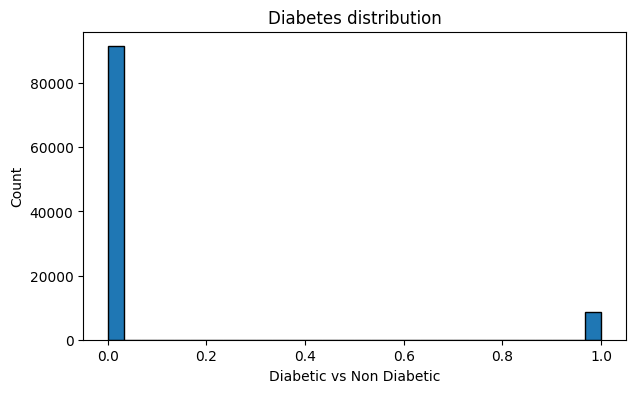

In [10]:
#Let's look at the target's distribution
plt.figure(figsize=(7,4))
plt.hist(df['diabetes'].dropna(),bins=30,edgecolor='black')
plt.xlabel('Diabetic vs Non Diabetic')
plt.ylabel('Count')
plt.title('Diabetes distribution')
plt.show()

In [11]:
df['diabetes'].value_counts()#finding how many diabetic and non diabetic people do we have in this dataset?

,count
diabetes,
0,91500
1,8500


In [12]:
df.describe()#summary of the dataset

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


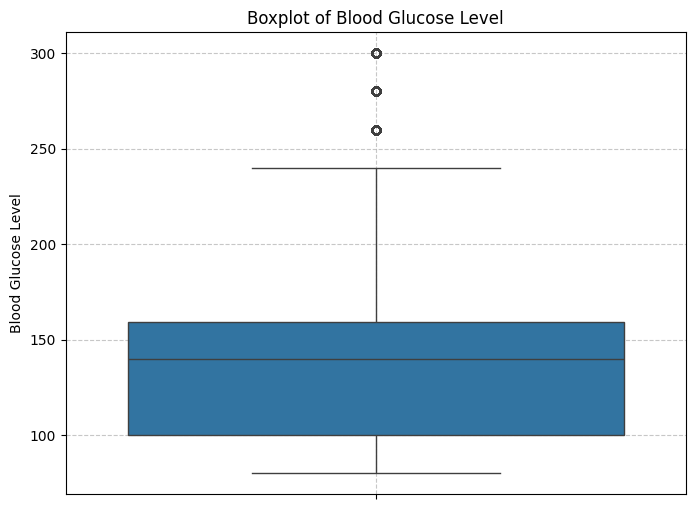

In [13]:
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(y=df['blood_glucose_level'])
plt.title('Boxplot of Blood Glucose Level')
plt.ylabel('Blood Glucose Level')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Filtering Outliers using IQR
To filter outliers, we'll calculate the Interquartile Range (IQR) for the blood_glucose_level feature. The IQR is the range between the first quartile (Q1) and the third quartile (Q3). Outliers are typically defined as values that fall outside of 1.5 times the IQR below Q1 or above Q3.

In [14]:
# Calculate Q1, Q3, and IQR for 'blood_glucose_level'
Q1 = df['blood_glucose_level'].quantile(0.25)
Q3 = df['blood_glucose_level'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out the outliers (keep values within the bounds)
df_no_outliers = df[(df['blood_glucose_level'] > lower_bound) & (df['blood_glucose_level'] < upper_bound)]

print(f"Original DataFrame shape: {df.shape}")
print(f"DataFrame shape after removing outliers: {df_no_outliers.shape}")

display(df_no_outliers.head())

Original DataFrame shape: (100000, 9)
DataFrame shape after removing outliers: (97962, 9)


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


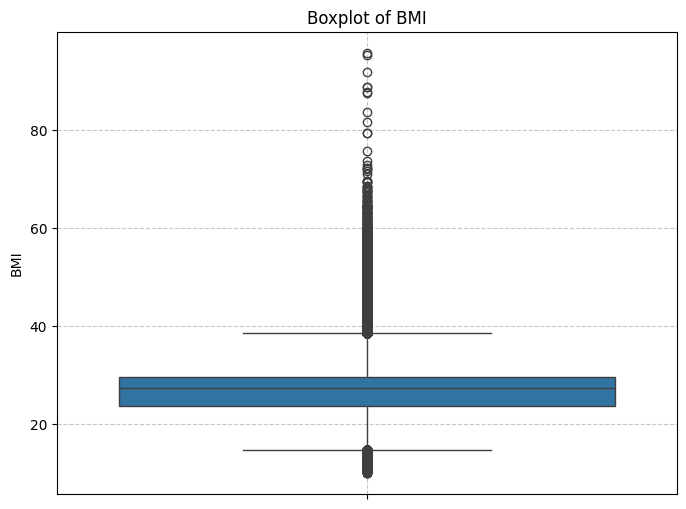

In [15]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['bmi'])
plt.title('Boxplot of BMI')
plt.ylabel('BMI')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Scaling Categorical Features

I will now process the categorical features. I'll drop the 'gender' column as the 'Other' category might not be useful for prediction and can cause issues. Then, I'll apply one-hot encoding to the 'smoking_history' column to convert it into a numerical format suitable for machine learning models.

In [16]:
# Drop the 'gender' column due to the 'Other' category
df_processed = df_no_outliers.drop(columns=['gender'])

# Apply one-hot encoding to 'smoking_history'
df_processed = pd.get_dummies(df_processed, columns=['smoking_history'], drop_first=True)

print(f"DataFrame shape after processing categorical features: {df_processed.shape}")
display(df_processed.head())

DataFrame shape after processing categorical features: (97962, 12)


,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,80.0,0,1,25.19,6.6,140,0,False,False,False,True,False
1,54.0,0,0,27.32,6.6,80,0,False,False,False,False,False
2,28.0,0,0,27.32,5.7,158,0,False,False,False,True,False
3,36.0,0,0,23.45,5.0,155,0,True,False,False,False,False
4,76.0,1,1,20.14,4.8,155,0,True,False,False,False,False


## Splitting the Dataset into Training, Validation, and Test Sets

To prepare the data for model training and evaluation, I will split the `df_processed` DataFrame into three subsets: training, validation, and test sets. This ensures that the model is trained on one set of data, tuned on another, and finally evaluated on unseen data to assess its generalization performance. I'll use a 70/15/15 split for training, validation, and testing, respectively.

In [17]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df_processed.drop('diabetes', axis=1)
y = df_processed['diabetes']

# Split the data into training (70%) and temporary (30%) sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Split the temporary data into validation (15%) and test (15%) sets
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (68573, 11)
y_train shape: (68573,)
X_val shape: (14694, 11)
y_val shape: (14694,)
X_test shape: (14695, 11)
y_test shape: (14695,)


## Scaling Numerical Features

To ensure that all numerical features contribute equally to the model training and to prevent features with larger values from dominating, I will apply standardization using `StandardScaler` from `sklearn.preprocessing`. This will transform the data to have a mean of 0 and a standard deviation of 1. I'll fit the scaler on the training data (`X_train`) and then transform `X_train`, `X_val`, and `X_test` using this fitted scaler to avoid data leakage.

In [18]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Transform the validation and test data using the fitted scaler
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Shape of scaled training data:", X_train_scaled.shape)
print("Shape of scaled validation data:", X_val_scaled.shape)
print("Shape of scaled test data:", X_test_scaled.shape)

# Display a small part of the scaled training data
print("\nFirst 5 rows of scaled training data:")
display(pd.DataFrame(X_train_scaled, columns=X_train.columns).head())

Shape of scaled training data: (68573, 11)
Shape of scaled validation data: (14694, 11)
Shape of scaled test data: (14695, 11)

First 5 rows of scaled training data:


,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,0.551969,-0.2775,-0.197366,-0.593901,1.044587,-1.414356,-0.318568,-0.201556,-0.319068,1.360526,-0.261658
1,0.329881,-0.2775,-0.197366,0.256407,0.283632,-0.145414,-0.318568,-0.201556,-0.319068,1.360526,-0.261658
2,-1.535657,-0.2775,-0.197366,0.016069,-1.904113,0.672348,-0.318568,-0.201556,-0.319068,-0.735010,-0.261658
3,-1.313569,-0.2775,-0.197366,-0.814464,-0.477322,0.277566,-0.318568,-0.201556,-0.319068,1.360526,-0.261658
4,-0.425218,-0.2775,-0.197366,0.016069,0.188513,-0.145414,-0.318568,-0.201556,-0.319068,1.360526,-0.261658


## Handling Class Imbalance with SMOTE

The target variable `diabetes` is imbalanced, with a much larger number of non-diabetic cases. To address this, I will use Synthetic Minority Over-sampling Technique (SMOTE) to generate synthetic samples for the minority class (diabetes=1) in the training set. This will help prevent the model from being biased towards the majority class.

It's important to apply SMOTE *after* splitting the data and *after* scaling numerical features to avoid data leakage and ensure fair evaluation.

In [19]:
from imblearn.over_sampling import SMOTE

# Convert y_train, y_val, y_test from Series to numpy arrays if not already
y_train_np = y_train.values if isinstance(y_train, pd.Series) else y_train
y_val_np = y_val.values if isinstance(y_val, pd.Series) else y_val
y_test_np = y_test.values if isinstance(y_test, pd.Series) else y_test

# Convert y_train to a 1D array if it's not already, for SMOTE compatibility
y_train_smote = y_train_np.ravel() if y_train_np.ndim > 1 else y_train_np

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train_smote)

print(f"Original training data shape: {X_train_scaled.shape}, {y_train_smote.shape}")
print(f"Resampled training data shape: {X_train_resampled.shape}, {y_train_resampled.shape}")

# Display class distribution after SMOTE
unique, counts = np.unique(y_train_resampled, return_counts=True)
print("Class distribution after SMOTE:", dict(zip(unique, counts)))

Original training data shape: (68573, 11), (68573,)
Resampled training data shape: (128100, 11), (128100,)
Class distribution after SMOTE: {np.int64(0): np.int64(64050), np.int64(1): np.int64(64050)}


## Creating PyTorch Datasets and DataLoaders (Updated for Imbalance)

Now, I will re-create the PyTorch `Dataset` and `DataLoader` objects for the training set using the SMOTE-resampled data. The validation and test sets remain unchanged.

In [20]:
from torch.utils.data import Dataset, DataLoader

class DiabetesDataset(Dataset):
    def __init__(self, features, targets):
        # Convert numpy arrays to torch tensors, ensuring float32 for features
        # and long for targets (for CrossEntropyLoss if applicable, or float32 for binary)
        self.features = torch.tensor(features, dtype=torch.float32)
        self.targets = torch.tensor(targets, dtype=torch.float32).unsqueeze(1) # unsqueeze for binary classification

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx], self.targets[idx]

# Create Dataset instances with resampled training data
train_dataset = DiabetesDataset(X_train_resampled, y_train_resampled)
val_dataset = DiabetesDataset(X_val_scaled, y_val_np)
test_dataset = DiabetesDataset(X_test_scaled, y_test_np)

# Define batch size
batch_size = 64

# Create DataLoader instances
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Number of batches in training loader (resampled): {len(train_loader)}")
print(f"Number of batches in validation loader: {len(val_loader)}")
print(f"Number of batches in test loader: {len(test_loader)}")

# Example of one batch from the resampled train_loader
for features, targets in train_loader:
    print("\nExample batch from resampled train_loader:")
    print(f"Features shape: {features.shape}")
    print(f"Targets shape: {targets.shape}")
    break

Number of batches in training loader (resampled): 2002
Number of batches in validation loader: 230
Number of batches in test loader: 230

Example batch from resampled train_loader:
Features shape: torch.Size([64, 11])
Targets shape: torch.Size([64, 1])


## Building a Neural Network with PyTorch (Baseline Model)

I will now define a simple feedforward neural network (Multi-Layer Perceptron) using PyTorch's `nn.Module`. The network will consist of several linear layers with ReLU activation functions, and a final output layer with a sigmoid activation function, suitable for binary classification. This will serve as our baseline model.

In [21]:
# Get the input size from the scaled training data
input_size = X_train_scaled.shape[1]

# Define the neural network architecture using nn.Sequential
# (Re-defining to ensure it's fresh for training)
model = nn.Sequential(
    nn.Linear(input_size, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 1),
    nn.Sigmoid()
).to(device)

print(model)

Sequential(
  (0): Linear(in_features=11, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=1, bias=True)
  (5): Sigmoid()
)


## Training the Neural Network (Baseline Model)

Now, I will implement the training loop for the baseline model. This involves:
1.  **Defining Loss Function and Optimizer**: Using Binary Cross-Entropy Loss (`nn.BCELoss`) suitable for binary classification and the Adam optimizer.
2.  **Training Loop**: Iterating over a specified number of epochs.
    *   For each epoch, iterating through the `train_loader` to get mini-batches of data.
    *   Performing a **forward pass** to get predictions.
    *   **Calculating the loss** between predictions and actual targets.
    *   Performing **backpropagation** to compute gradients.
    *   **Updating weights** using the optimizer.
    *   **Resetting gradients** to zero for the next iteration.
3.  **Validation Loop**: After each training epoch, evaluating the model on the `val_loader` to monitor performance and identify potential overfitting. The model will be set to evaluation mode, and gradients will be disabled during this phase.

In [22]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Define loss function and optimizer
criterion = nn.BCELoss() # Binary Cross-Entropy Loss for binary classification
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Number of epochs
num_epochs = 20

# Store metrics for plotting
train_losses = []
val_losses = []
val_accuracies = []
val_f1_scores = []

for epoch in range(num_epochs):
    model.train() # Set model to training mode
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    # Validation phase
    model.eval() # Set model to evaluation mode
    val_running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad(): # Disable gradient calculation for validation
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item()

            preds = (outputs > 0.5).float() # Convert probabilities to binary predictions
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_loss = val_running_loss / len(val_loader)
    val_losses.append(val_loss)

    # Calculate validation metrics
    val_accuracy = accuracy_score(all_labels, all_preds)
    val_f1 = f1_score(all_labels, all_preds)
    val_accuracies.append(val_accuracy)
    val_f1_scores.append(val_f1)

    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}, Val F1-Score: {val_f1:.4f}")

print("Finished Training Baseline Model")

Epoch 1/20, Train Loss: 0.2649, Val Loss: 0.2827, Val Accuracy: 0.8569, Val F1-Score: 0.4580
Epoch 2/20, Train Loss: 0.2339, Val Loss: 0.2472, Val Accuracy: 0.8725, Val F1-Score: 0.4810
Epoch 3/20, Train Loss: 0.2251, Val Loss: 0.2398, Val Accuracy: 0.8715, Val F1-Score: 0.4799
Epoch 4/20, Train Loss: 0.2199, Val Loss: 0.2137, Val Accuracy: 0.8836, Val F1-Score: 0.4960
Epoch 5/20, Train Loss: 0.2158, Val Loss: 0.2275, Val Accuracy: 0.8798, Val F1-Score: 0.4957
Epoch 6/20, Train Loss: 0.2125, Val Loss: 0.2263, Val Accuracy: 0.8782, Val F1-Score: 0.4948
Epoch 7/20, Train Loss: 0.2091, Val Loss: 0.2264, Val Accuracy: 0.8803, Val F1-Score: 0.4964
Epoch 8/20, Train Loss: 0.2070, Val Loss: 0.2406, Val Accuracy: 0.8680, Val F1-Score: 0.4751
Epoch 9/20, Train Loss: 0.2047, Val Loss: 0.2465, Val Accuracy: 0.8640, Val F1-Score: 0.4692
Epoch 10/20, Train Loss: 0.2030, Val Loss: 0.2221, Val Accuracy: 0.8782, Val F1-Score: 0.4900
Epoch 11/20, Train Loss: 0.2007, Val Loss: 0.2135, Val Accuracy: 0.88

### Baseline Model Performance

The model we have just trained will serve as our baseline. Let's record its performance on the test set for comparison.

In [23]:
# Evaluate Baseline Model on Test Set
model.eval() # Set model to evaluation mode
all_preds_baseline = []
all_labels_baseline = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        preds = (outputs > 0.5).float()
        all_preds_baseline.extend(preds.cpu().numpy())
        all_labels_baseline.extend(labels.cpu().numpy())

baseline_accuracy = accuracy_score(all_labels_baseline, all_preds_baseline)
baseline_precision = precision_score(all_labels_baseline, all_preds_baseline)
baseline_recall = recall_score(all_labels_baseline, all_preds_baseline)
baseline_f1 = f1_score(all_labels_baseline, all_preds_baseline)

print("Baseline Model Performance on Test Set:")
print(f"Accuracy: {baseline_accuracy:.4f}")
print(f"Precision: {baseline_precision:.4f}")
print(f"Recall: {baseline_recall:.4f}")
print(f"F1-Score: {baseline_f1:.4f}")

Baseline Model Performance on Test Set:
Accuracy: 0.9098
Precision: 0.4113
Recall: 0.8485
F1-Score: 0.5540


## Experiment & Model Improvement

Now that we have a baseline model, let's explore ways to improve its performance. We will compare our baseline model with an improved version that incorporates some common neural network improvements.

### Improved Model Architecture

For the improved model, I will:
- Add more layers and neurons to increase model capacity.
- Introduce `Dropout` layers to prevent overfitting.
- The model will use `nn.Linear` layers with `ReLU` activation functions, and a final `Sigmoid` for binary classification.

In [33]:
# Define the Improved Neural Network architecture using nn.Sequential
# More layers, more neurons, and dropout

class ImprovedDiabetesPredictor(nn.Module):
    def __init__(self, input_size):
        super(ImprovedDiabetesPredictor, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Dropout(0.35), # Added dropout
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.35), # Added dropout
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.layers(x)

# Instantiate the improved model
improved_model = ImprovedDiabetesPredictor(input_size).to(device)

print(improved_model)

ImprovedDiabetesPredictor(
  (layers): Sequential(
    (0): Linear(in_features=11, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.35, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.35, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Linear(in_features=32, out_features=1, bias=True)
    (9): Sigmoid()
  )
)


### Training the Improved Model with Early Stopping

For this improved model iteration, I will:
- Keep the architecture with more layers and neurons and `Dropout` layers to increase model capacity and prevent overfitting.
- Implement early stopping based on validation loss to prevent overfitting and optimize training time.
- Limit the maximum number of epochs to 20 to match the baseline training time.

In [34]:
# Train the Improved Model with Early Stopping

# Re-initialize criterion and optimizer for the new training run
criterion_improved = nn.BCELoss()
optimizer_improved = optim.SGD(improved_model.parameters(),momentum=0.9 ,lr=0.01) # Slightly lower learning rate

num_epochs_improved = 20 # User-requested epochs
patience = 5 # How many epochs to wait before stopping if validation loss doesn't improve
min_val_loss = float('inf')
epochs_no_improve = 0
best_model_state = None

train_losses_improved = []
val_losses_improved = []
val_accuracies_improved = []
val_f1_scores_improved = []

for epoch in range(num_epochs_improved):
    improved_model.train()
    running_loss_improved = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer_improved.zero_grad()
        outputs = improved_model(inputs)
        loss = criterion_improved(outputs, labels)
        loss.backward()
        optimizer_improved.step()

        running_loss_improved += loss.item()

    train_loss_improved = running_loss_improved / len(train_loader)
    train_losses_improved.append(train_loss_improved)

    # Validation phase for improved model
    improved_model.eval()
    val_running_loss_improved = 0.0
    all_preds_improved = []
    all_labels_improved = []

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = improved_model(inputs)
            loss = criterion_improved(outputs, labels)
            val_running_loss_improved += loss.item()

            preds = (outputs > 0.5).float()
            all_preds_improved.extend(preds.cpu().numpy())
            all_labels_improved.extend(labels.cpu().numpy())

    val_loss_improved = val_running_loss_improved / len(val_loader)
    val_losses_improved.append(val_loss_improved)

    val_accuracy_improved = accuracy_score(all_labels_improved, all_preds_improved)
    val_f1_improved = f1_score(all_labels_improved, all_preds_improved)
    val_accuracies_improved.append(val_accuracy_improved)
    val_f1_scores_improved.append(val_f1_improved)

    print(f"Improved Epoch {epoch+1}/{num_epochs_improved}, Train Loss: {train_loss_improved:.4f}, Val Loss: {val_loss_improved:.4f}, Val Accuracy: {val_accuracy_improved:.4f}, Val F1-Score: {val_f1_improved:.4f}")

    # Early stopping check
    if val_loss_improved < min_val_loss:
        min_val_loss = val_loss_improved
        epochs_no_improve = 0
        best_model_state = improved_model.state_dict() # Save best model state
    else:
        epochs_no_improve += 1
        if epochs_no_improve == patience:
            print(f"Early stopping after {epoch+1} epochs due to no improvement in validation loss.")
            break

# Load the best model state if early stopping occurred
if best_model_state is not None:
    improved_model.load_state_dict(best_model_state)
    print("Loaded best model state from early stopping.")

print("Finished Training Improved Model")

Improved Epoch 1/20, Train Loss: 0.3063, Val Loss: 0.2781, Val Accuracy: 0.8481, Val F1-Score: 0.4420
Improved Epoch 2/20, Train Loss: 0.2565, Val Loss: 0.2405, Val Accuracy: 0.8687, Val F1-Score: 0.4767
Improved Epoch 3/20, Train Loss: 0.2417, Val Loss: 0.2313, Val Accuracy: 0.8679, Val F1-Score: 0.4784
Improved Epoch 4/20, Train Loss: 0.2308, Val Loss: 0.2422, Val Accuracy: 0.8632, Val F1-Score: 0.4708
Improved Epoch 5/20, Train Loss: 0.2226, Val Loss: 0.2221, Val Accuracy: 0.8708, Val F1-Score: 0.4821
Improved Epoch 6/20, Train Loss: 0.2169, Val Loss: 0.2247, Val Accuracy: 0.8684, Val F1-Score: 0.4754
Improved Epoch 7/20, Train Loss: 0.2145, Val Loss: 0.2007, Val Accuracy: 0.8832, Val F1-Score: 0.5015
Improved Epoch 8/20, Train Loss: 0.2123, Val Loss: 0.2311, Val Accuracy: 0.8618, Val F1-Score: 0.4680
Improved Epoch 9/20, Train Loss: 0.2107, Val Loss: 0.1994, Val Accuracy: 0.8849, Val F1-Score: 0.5048
Improved Epoch 10/20, Train Loss: 0.2101, Val Loss: 0.2195, Val Accuracy: 0.8691, 

### Improved Model Performance

Let's evaluate the performance of the improved model on the test set.

In [35]:
# Evaluate Improved Model on Test Set
improved_model.eval()
all_preds_test_improved = []
all_labels_test_improved = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = improved_model(inputs)
        preds = (outputs > 0.5).float()
        all_preds_test_improved.extend(preds.cpu().numpy())
        all_labels_test_improved.extend(labels.cpu().numpy())

improved_accuracy = accuracy_score(all_labels_test_improved, all_preds_test_improved)
improved_precision = precision_score(all_labels_test_improved, all_preds_test_improved)
improved_recall = recall_score(all_labels_test_improved, all_preds_test_improved)
improved_f1 = f1_score(all_labels_test_improved, all_preds_test_improved)

print("Improved Model Performance on Test Set:")
print(f"Accuracy: {improved_accuracy:.4f}")
print(f"Precision: {improved_precision:.4f}")
print(f"Recall: {improved_recall:.4f}")
print(f"F1-Score: {improved_f1:.4f}")

Improved Model Performance on Test Set:
Accuracy: 0.8810
Precision: 0.3481
Recall: 0.9206
F1-Score: 0.5052


### Model Performance Comparison

Let's compare the performance metrics of the Baseline Model and the Improved Model on the test set.

In [36]:
import pandas as pd

comparison_data = {
    'Model': ['Baseline Model', 'Improved Model'],
    'Accuracy': [baseline_accuracy, improved_accuracy],
    'Precision': [baseline_precision, improved_precision],
    'Recall': [baseline_recall, improved_recall],
    'F1-Score': [baseline_f1, improved_f1]
}

comparison_df = pd.DataFrame(comparison_data)
display(comparison_df.round(4))

,Model,Accuracy,Precision,Recall,F1-Score
0,Baseline Model,0.9098,0.4113,0.8485,0.5540
1,Improved Model,0.8810,0.3481,0.9206,0.5052


### Training and Validation Loss Comparison

Let's visualize the training and validation losses for the Baseline Model and the Improved Model to observe their learning curves and identify any overfitting or underfitting trends.

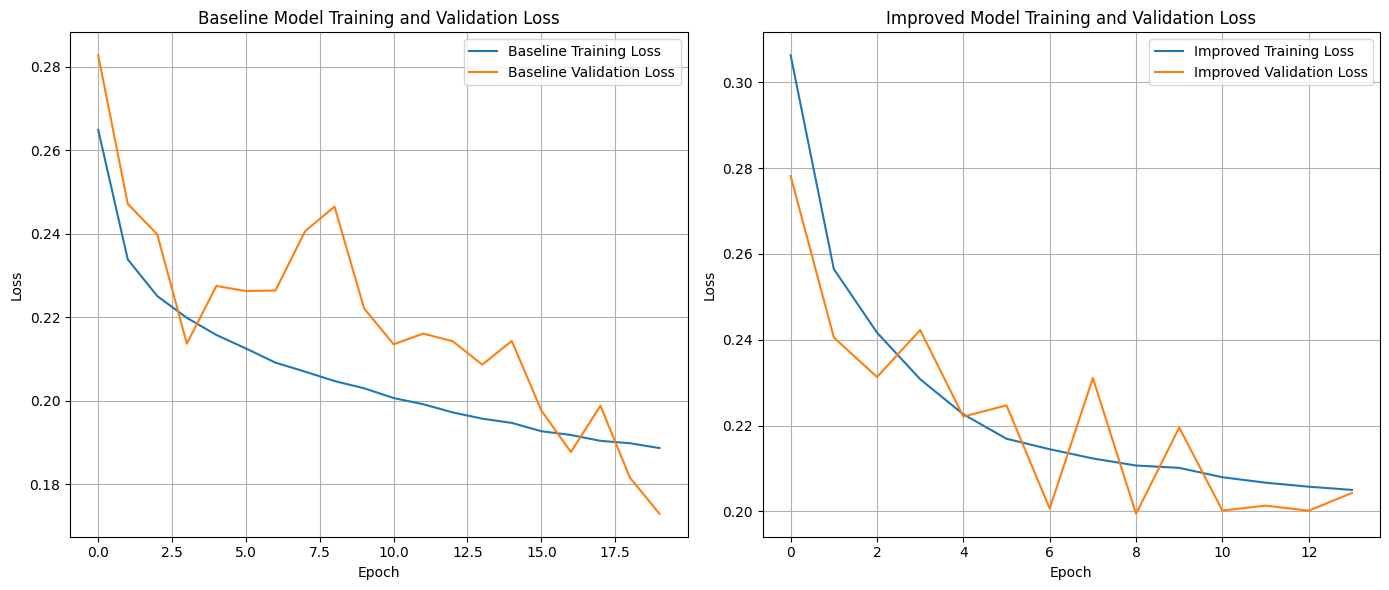

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# Subplot 1: Baseline Model Losses
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.plot(train_losses, label='Baseline Training Loss')
plt.plot(val_losses, label='Baseline Validation Loss')
plt.title('Baseline Model Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Subplot 2: Improved Model Losses
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.plot(train_losses_improved, label='Improved Training Loss')
plt.plot(val_losses_improved, label='Improved Validation Loss')
plt.title('Improved Model Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

### Confusion Matrices

Let's visualize the confusion matrices for both the Baseline Model and the Improved Model to get a detailed view of their classification performance.

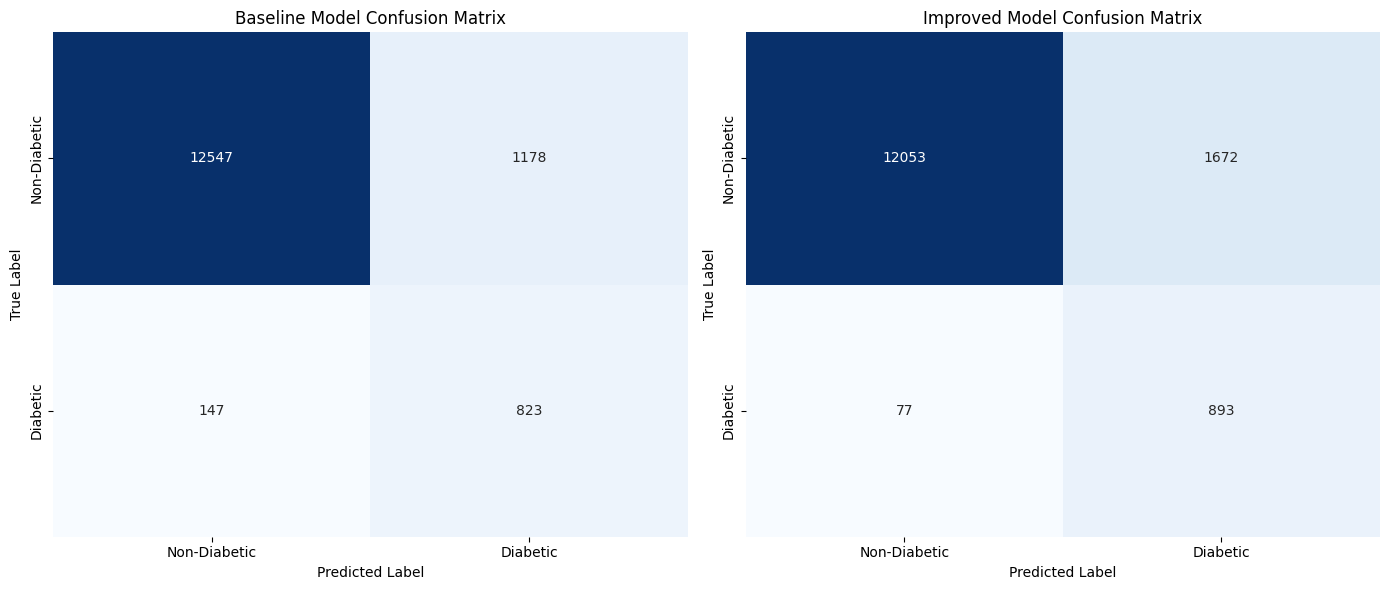

In [39]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Function to plot confusion matrix
def plot_confusion_matrix(ax, cm, title):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    ax.set_xticklabels(['Non-Diabetic', 'Diabetic'])
    ax.set_yticklabels(['Non-Diabetic', 'Diabetic'])

# Calculate confusion matrix for Baseline Model
cm_baseline = confusion_matrix(all_labels_baseline, all_preds_baseline)

# Calculate confusion matrix for Improved Model
cm_improved = confusion_matrix(all_labels_test_improved, all_preds_test_improved)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot Baseline Model Confusion Matrix
plot_confusion_matrix(axes[0], cm_baseline, 'Baseline Model Confusion Matrix')

# Plot Improved Model Confusion Matrix
plot_confusion_matrix(axes[1], cm_improved, 'Improved Model Confusion Matrix')

plt.tight_layout()
plt.show()

## 10. Save & Reload Your Model

To ensure our trained model and preprocessing steps can be reused, we will save the model's weights and the `StandardScaler` object. Then, we will reload them to confirm that predictions remain consistent, demonstrating that the saving and reloading process works correctly.

In [40]:
import joblib

# Define paths for saving
model_save_path = '/content/drive/MyDrive/pima-diabetes/baseline_model.pth'
scaler_save_path = '/content/drive/MyDrive/pima-diabetes/scaler.joblib'

# 1. Save Model Weights (state_dict)
torch.save(model.state_dict(), model_save_path)
print(f"Baseline Model weights saved to: {model_save_path}")

# 2. Save the StandardScaler object
joblib.dump(scaler, scaler_save_path)
print(f"Scaler object saved to: {scaler_save_path}")

Baseline Model weights saved to: /content/drive/MyDrive/pima-diabetes/baseline_model.pth
Scaler object saved to: /content/drive/MyDrive/pima-diabetes/scaler.joblib


### Reloading Model and Scaler

Now, let's reload the saved model weights into a new model instance and load the saved scaler.

In [41]:
# Re-instantiate the model with the same architecture
# (Ensure the `model` architecture is defined or re-defined before this step)
reloaded_model = nn.Sequential(
    nn.Linear(input_size, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 1),
    nn.Sigmoid()
).to(device)

# Load the saved state_dict
reloaded_model.load_state_dict(torch.load(model_save_path))
reloaded_model.eval() # Set to evaluation mode
print("Baseline Model reloaded successfully!")

# Load the scaler
reloaded_scaler = joblib.load(scaler_save_path)
print("Scaler reloaded successfully!")

Baseline Model reloaded successfully!
Scaler reloaded successfully!


### Confirming Prediction Consistency

To confirm that the reloaded model and scaler are working as expected, we'll make predictions on a small sample of the test set using both the original and reloaded objects and compare the results.

In [43]:
# Take a small sample from the original X_test (before scaling)
sample_X = X_test.head(50)

# Use the original scaler to transform the sample
sample_X_scaled_original = scaler.transform(sample_X)
sample_X_tensor_original = torch.tensor(sample_X_scaled_original, dtype=torch.float32).to(device)

# Use the reloaded scaler to transform the sample
sample_X_scaled_reloaded = reloaded_scaler.transform(sample_X)
sample_X_tensor_reloaded = torch.tensor(sample_X_scaled_reloaded, dtype=torch.float32).to(device)

# Make predictions with the original model
with torch.no_grad():
    original_model_predictions = (model(sample_X_tensor_original) > 0.5).float().cpu().numpy().flatten()

# Make predictions with the reloaded model
with torch.no_grad():
    reloaded_model_predictions = (reloaded_model(sample_X_tensor_reloaded) > 0.5).float().cpu().numpy().flatten()

print("Original Model Predictions:", original_model_predictions)
print("Reloaded Model Predictions:", reloaded_model_predictions)

# Check for consistency
if np.array_equal(original_model_predictions, reloaded_model_predictions):
    print("\nPredictions are consistent between original and reloaded models.")
else:
    print("\nWARNING: Predictions are NOT consistent between original and reloaded models.")

Original Model Predictions: [0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0.
 0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0.]
Reloaded Model Predictions: [0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0.
 0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0.]

Predictions are consistent between original and reloaded models.
